<a href="https://colab.research.google.com/github/Yxtsu-unu/CI345---ML/blob/main/Updated_ML_Final_Project_Disicpline_vs_Distraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ML - Final Project
###Disicpline vs Distraction Dataset
#Research Question: Can we predict procrastination levels from a student's behavioral profile including academic outcomes?

# Step 1 -- Loading Data


In [5]:
import pandas as pd
import numpy as np

from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
distraction_file = '/content/drive/MyDrive/CI345_ML/data/procrastination_dataset.csv'

df = pd.read_csv(distraction_file)

print(df.head(3))
print(df.columns)
print("Dataset Shape: ", df.shape)

Mounted at /content/drive
   user_id  study_hrs  sleep_hrs  screen_time_by_day  social_media_time  \
0        1        5.9        5.9                 9.0                3.9   
1        2        3.1        4.8                 9.3                6.1   
2        3        1.5        5.5                 9.7                4.3   

   task_delay_min  focus_score  stress_lvl  motivation_lvl  \
0             142            1           9               4   
1              81            2           5               4   
2              89            3           4               4   

   study_session_length  ...  caffeine_intake  multitasking_lvl  \
0                    61  ...                5            Medium   
1                    59  ...                0            Medium   
2                    61  ...                2               Low   

   study_environment  peak_productivity  deadline difficulty_lvl  \
0           Moderate          Afternoon  Flexible           Hard   
1              Nois

#Step 2 -- Data Analysis



In [6]:
#Creating copy of original data set
df.copy()

#Dropping Column User ID - No correlation to the dataset
df.drop(columns=['user_id'], inplace=True)
# Show Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hrs              2000 non-null   float64
 1   sleep_hrs              2000 non-null   float64
 2   screen_time_by_day     2000 non-null   float64
 3   social_media_time      2000 non-null   float64
 4   task_delay_min         2000 non-null   int64  
 5   focus_score            2000 non-null   int64  
 6   stress_lvl             2000 non-null   int64  
 7   motivation_lvl         2000 non-null   int64  
 8   study_session_length   2000 non-null   int64  
 9   break_frequency        2000 non-null   int64  
 10  notifications_per_day  2000 non-null   int64  
 11  phone_use_per_day      2000 non-null   int64  
 12  exercise_min           2000 non-null   int64  
 13  caffeine_intake        2000 non-null   int64  
 14  multitasking_lvl       2000 non-null   object 
 15  stud

In [7]:

#Show number rows and columns
df.shape

(2000, 23)

In [8]:
#Show column names
df.columns

Index(['study_hrs', 'sleep_hrs', 'screen_time_by_day', 'social_media_time',
       'task_delay_min', 'focus_score', 'stress_lvl', 'motivation_lvl',
       'study_session_length', 'break_frequency', 'notifications_per_day',
       'phone_use_per_day', 'exercise_min', 'caffeine_intake',
       'multitasking_lvl', 'study_environment', 'peak_productivity',
       'deadline', 'difficulty_lvl', 'deadline_urgency', 'productivity_score',
       'completion_rate', 'procrastination_lvl'],
      dtype='object')

In [9]:
#Show data types
df.dtypes

,0
study_hrs,float64
sleep_hrs,float64
screen_time_by_day,float64
social_media_time,float64
task_delay_min,int64
focus_score,int64
stress_lvl,int64
motivation_lvl,int64
study_session_length,int64
break_frequency,int64


In [10]:
#Show missing data
df.isnull().sum()

,0
study_hrs,0
sleep_hrs,0
screen_time_by_day,0
social_media_time,0
task_delay_min,0
focus_score,0
stress_lvl,0
motivation_lvl,0
study_session_length,0
break_frequency,0


In [11]:
#Show descriptive statistics
df.describe()

,study_hrs,sleep_hrs,screen_time_by_day,social_media_time,task_delay_min,focus_score,stress_lvl,motivation_lvl,study_session_length,break_frequency,notifications_per_day,phone_use_per_day,exercise_min,caffeine_intake,productivity_score,completion_rate
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,5.45240,5.445250,7.920450,5.179850,70.966500,3.40250,5.221000,4.984500,74.481500,4.341500,119.194500,53.020500,20.088000,2.033500,2.814900,94.558000
std,2.70287,1.077306,1.766272,1.642601,46.777136,2.37725,2.256037,2.269104,20.856274,2.149928,31.882251,11.289057,14.256889,1.405121,2.291585,11.184059
min,0.00000,4.000000,2.100000,1.000000,0.000000,-2.00000,1.000000,1.000000,10.000000,0.000000,10.000000,14.000000,0.000000,0.000000,1.000000,31.000000
25%,3.40000,4.500000,6.800000,4.000000,34.000000,1.00000,3.000000,3.000000,60.000000,3.000000,98.750000,46.000000,9.000000,1.000000,1.000000,95.000000
50%,5.50000,5.400000,8.200000,5.100000,68.000000,3.00000,5.000000,5.000000,75.000000,4.000000,119.000000,53.000000,19.000000,2.000000,1.600000,100.000000
75%,7.60000,6.200000,9.500000,6.400000,105.000000,5.00000,7.000000,7.000000,89.000000,6.000000,141.000000,61.000000,30.000000,3.000000,4.300000,100.000000
max,10.00000,9.000000,10.000000,9.000000,180.000000,10.00000,11.000000,10.000000,120.000000,11.000000,200.000000,80.000000,60.000000,5.000000,10.000000,100.000000


In [12]:
#Target Distrubution
print(df['procrastination_lvl'].value_counts())

print("\nClass proportions:")
print(df['procrastination_lvl'].value_counts(normalize=True).round(3))

procrastination_lvl
Low       1102
Medium     509
High       389
Name: count, dtype: int64

Class proportions:
procrastination_lvl
Low       0.551
Medium    0.254
High      0.194
Name: proportion, dtype: float64


In [13]:
#Confirming the features arent mispelled.

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col}: {df[col].unique().tolist()}")

multitasking_lvl: ['Low', 'Medium', 'High']
study_environment: ['Quiet', 'Moderate', 'Noisy']
peak_productivity: ['Morning', 'Afternoon', 'Night']
deadline: ['Flexible', 'Strict']
difficulty_lvl: ['Easy', 'Medium', 'Hard']
deadline_urgency: ['Low', 'Medium', 'High']

multitasking_lvl: ['Medium', 'Low', 'High']
study_environment: ['Moderate', 'Noisy', 'Quiet']
peak_productivity: ['Afternoon', 'Night', 'Morning']
deadline: ['Flexible', 'Strict']
difficulty_lvl: ['Hard', 'Medium', 'Easy']
deadline_urgency: ['Low', 'Medium', 'High']
procrastination_lvl: ['High', 'Medium', 'Low']


#Step 3 -- Data Visualization

/tmp/ipykernel_6862/928907590.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='procrastination_lvl',


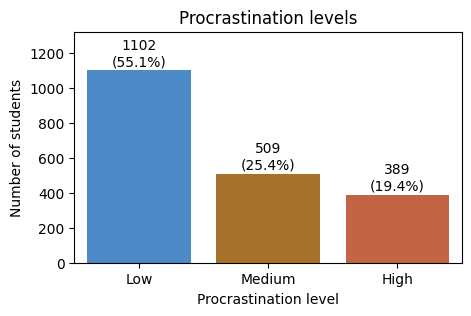

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
ax = sns.countplot(data=df, x='procrastination_lvl',
                   order=['Low', 'Medium', 'High'],
                   palette={'Low':'#378ADD', 'Medium':'#BA7517', 'High':'#D85A30'})

# Add counts and percentages
for bar in ax.patches:
    count = bar.get_height()
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            count + 10,
            f'{int(count)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10)

plt.title('Procrastination levels')
plt.xlabel('Procrastination level')
plt.ylabel('Number of students')
plt.ylim(0, df['procrastination_lvl'].value_counts().max() * 1.2)
plt.show()

/tmp/ipykernel_6862/4052353631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='procrastination_lvl', y='completion_rate',


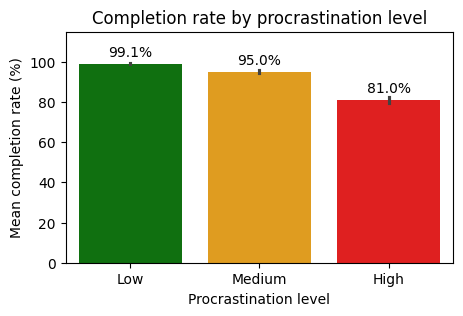

In [15]:
plt.figure(figsize=(5, 3))
ax = sns.barplot(data=df, x='procrastination_lvl', y='completion_rate',
                 order=['Low', 'Medium', 'High'],
                 palette={'Low':'green', 'Medium':'orange', 'High':'red'})

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Completion rate by procrastination level')
plt.xlabel('Procrastination level')
plt.ylabel('Mean completion rate (%)')
plt.ylim(0, 115)
plt.show()

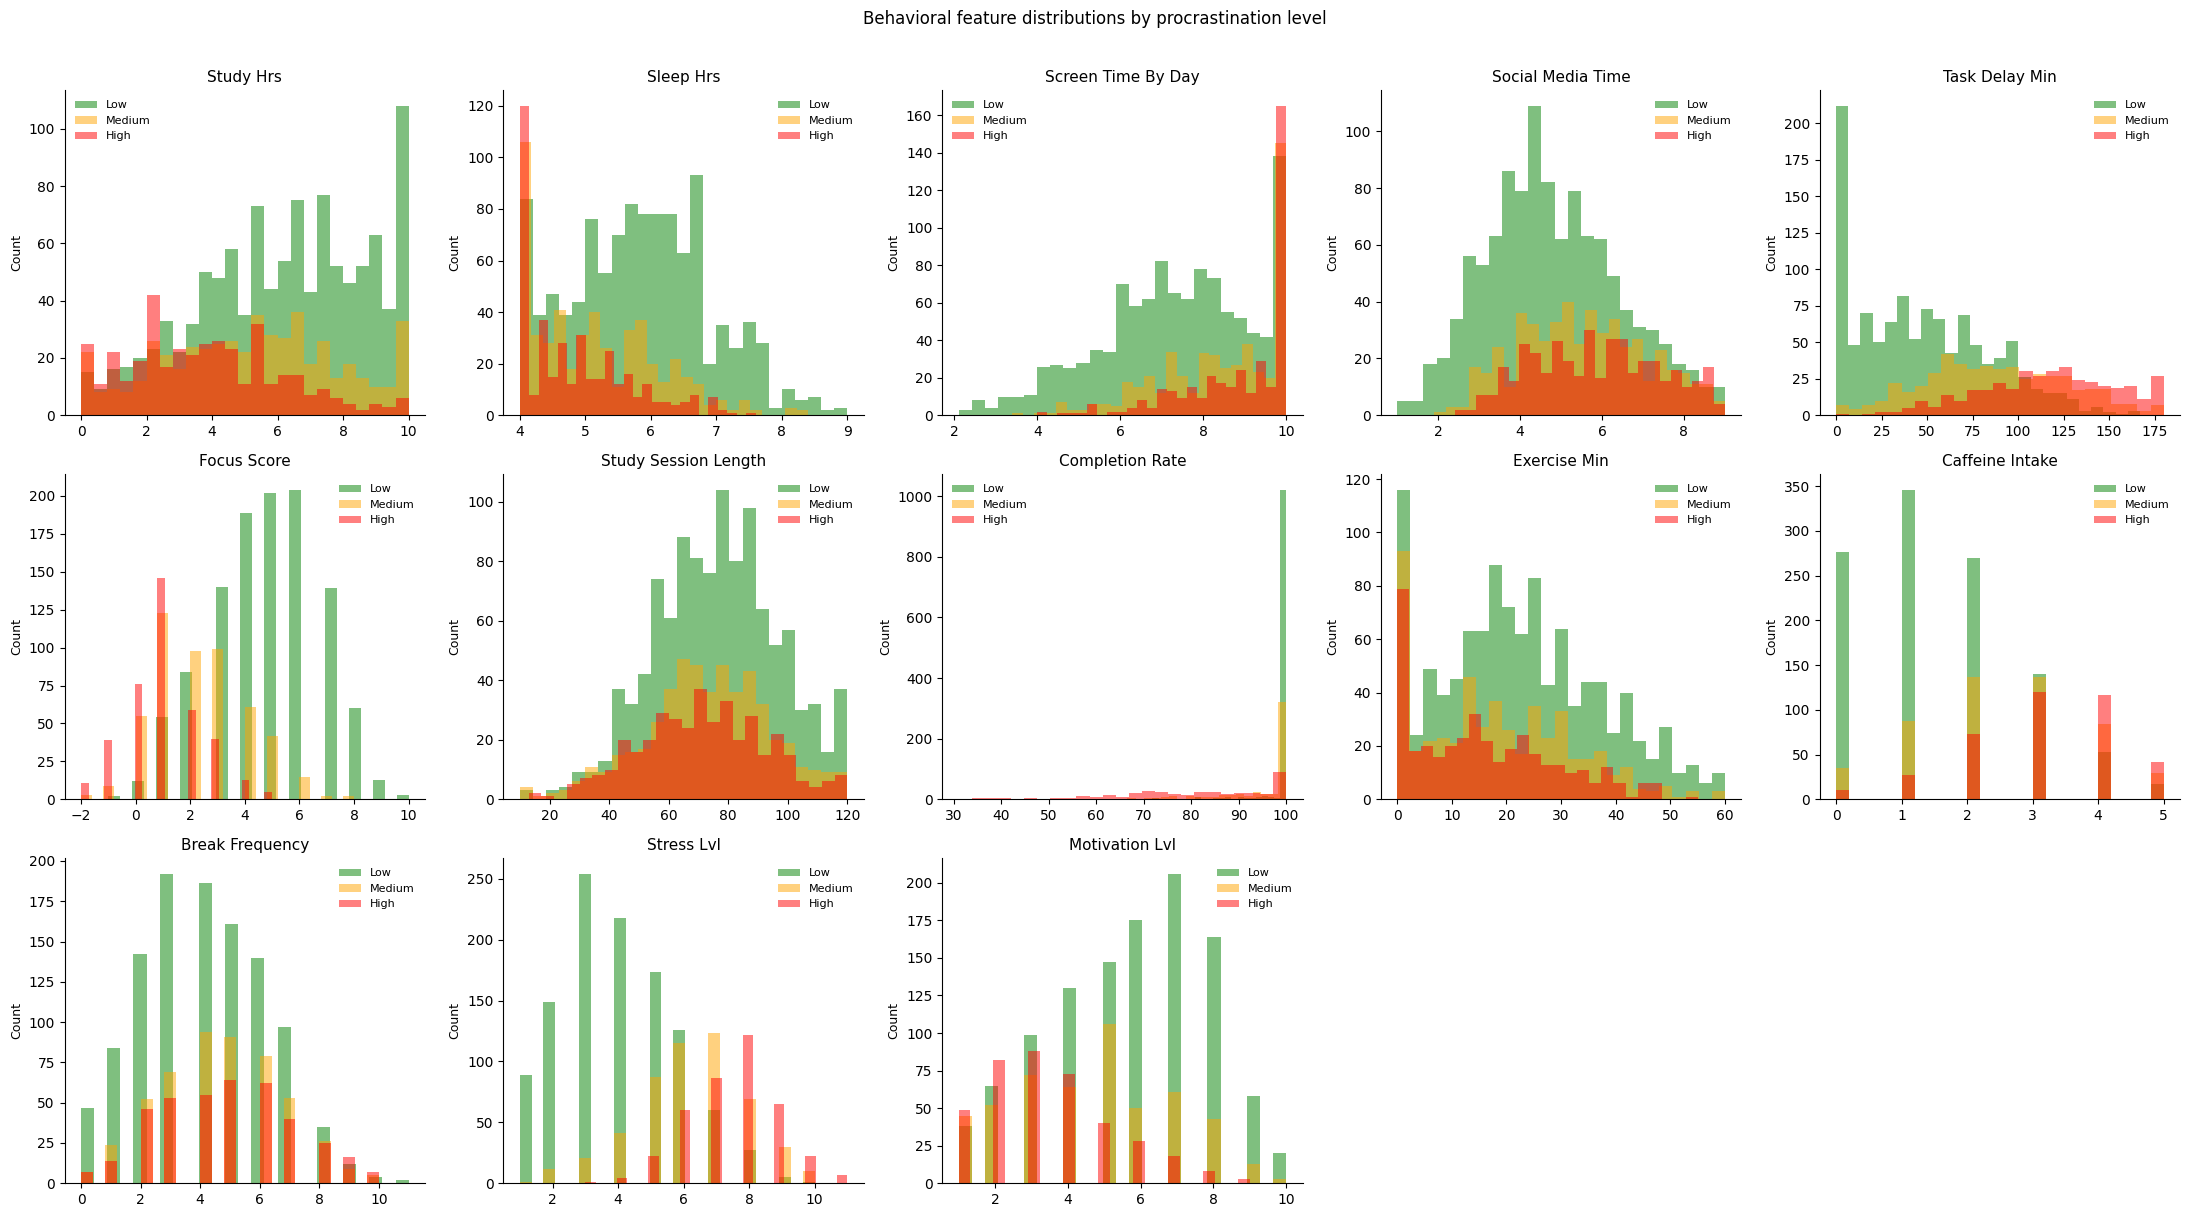

In [16]:
behavioral_features = [
    'study_hrs', 'sleep_hrs', 'screen_time_by_day', 'social_media_time',
    'task_delay_min', 'focus_score', 'study_session_length', 'completion_rate',
    'exercise_min', 'caffeine_intake', 'break_frequency',
    'stress_lvl', 'motivation_lvl'
]

colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for i, (feat, ax) in enumerate(zip(behavioral_features, axes)):
    for lvl, color in colors.items():
        sns.histplot(data=df[df['procrastination_lvl'] == lvl],
                     x=feat, bins=25, alpha=0.5, color=color,
                     label=lvl, ax=ax, edgecolor='none')
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

[ax.set_visible(False) for ax in axes[len(behavioral_features):]]

plt.suptitle('Behavioral feature distributions by procrastination level', y=1.01)
plt.tight_layout()
plt.show()

# Step 4 -- Data Processing

In [17]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

#Ordinal encode — preserve Low < Medium < High order
ord_enc = OrdinalEncoder(categories=[
    ['Low', 'Medium', 'High'],   # multitasking_lvl
    ['Easy', 'Medium', 'Hard'],  # difficulty_lvl
    ['Low', 'Medium', 'High'],   # deadline_urgency
])

ord_cols = ['multitasking_lvl', 'difficulty_lvl', 'deadline_urgency']
df[ord_cols] = ord_enc.fit_transform(df[ord_cols])

#One-hot encode
df = pd.get_dummies(df, columns=['study_environment', 'peak_productivity'])

#Binary encode
df['deadline'] = (df['deadline'] == 'Strict').astype(int)

#Encoding target
le = LabelEncoder()
df['procrastination_lvl_enc'] = le.fit_transform(df['procrastination_lvl'])

print(df.shape)
print(df.dtypes.value_counts())

(2000, 28)
int64      13
float64     8
bool        6
object      1
Name: count, dtype: int64


In [18]:
print(df.select_dtypes(include='object').columns.tolist())
# Should only show ['procrastination_lvl'] — the original label kept for reference

['procrastination_lvl']


#Step 5 -- Seperating Data and target

In [19]:
print(df.columns)

#Seperating Features

col = ['study_hrs', 'sleep_hrs', 'screen_time_by_day', 'social_media_time',
       'task_delay_min', 'focus_score', 'stress_lvl', 'motivation_lvl',
       'study_session_length', 'break_frequency', 'notifications_per_day',
       'phone_use_per_day', 'exercise_min', 'caffeine_intake',
       'multitasking_lvl', 'deadline', 'difficulty_lvl', 'deadline_urgency',
       'productivity_score', 'completion_rate',
       'study_environment_Moderate', 'study_environment_Noisy',
       'study_environment_Quiet', 'peak_productivity_Afternoon',
       'peak_productivity_Morning', 'peak_productivity_Night']

# Data
X = df[col]

# Target
y = df['procrastination_lvl_enc']

print(X.shape)
print(y.shape)
print("---------------")
print(y.head(2))
print(X.head(3))

Index(['study_hrs', 'sleep_hrs', 'screen_time_by_day', 'social_media_time',
       'task_delay_min', 'focus_score', 'stress_lvl', 'motivation_lvl',
       'study_session_length', 'break_frequency', 'notifications_per_day',
       'phone_use_per_day', 'exercise_min', 'caffeine_intake',
       'multitasking_lvl', 'deadline', 'difficulty_lvl', 'deadline_urgency',
       'productivity_score', 'completion_rate', 'procrastination_lvl',
       'study_environment_Moderate', 'study_environment_Noisy',
       'study_environment_Quiet', 'peak_productivity_Afternoon',
       'peak_productivity_Morning', 'peak_productivity_Night',
       'procrastination_lvl_enc'],
      dtype='object')
(2000, 26)
(2000,)
---------------
0    0
1    2
Name: procrastination_lvl_enc, dtype: int64
   study_hrs  sleep_hrs  screen_time_by_day  social_media_time  \
0        5.9        5.9                 9.0                3.9   
1        3.1        4.8                 9.3                6.1   
2        1.5        5.5   

#Step 6 -- Training Classifiers

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test  = train_test_split (X, y, random_state = 42, test_size = 0.2)

    #Review the data and target
print('-- Split Data -- ')
print(X_train.shape)
print(X_test.shape)
print()
print('-- Split Target --')
print(y_train.shape)
print(y_test.shape)

-- Split Data -- 
(1600, 26)
(400, 26)

-- Split Target --
(1600,)
(400,)


In [21]:
        # Show training and testing data
print('\t-- Checking Split Data -- ')
print()
print(X_train[:3])
print(X_test[:3])
print()
print('\t-- Checking Target Data -- ')
print()
print(y_train[:3])
print(y_test[:3])

	-- Checking Split Data -- 

     study_hrs  sleep_hrs  screen_time_by_day  social_media_time  \
968        4.0        4.3                 8.1                5.1   
240        4.2        8.6                 7.8                5.3   
819        6.3        5.8                 8.2                4.8   

     task_delay_min  focus_score  stress_lvl  motivation_lvl  \
968              70            0           9               7   
240               0            8           2               5   
819              10            7           2               8   

     study_session_length  break_frequency  ...  difficulty_lvl  \
968                    80                4  ...             2.0   
240                    87                2  ...             1.0   
819                   113                1  ...             2.0   

     deadline_urgency  productivity_score  completion_rate  \
968               2.0                 2.5              100   
240               2.0                 5.2       

#Classifier 1 -- Standard Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Create Logistic Regression Classifier
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)

# Step 2: Training (Use X_train instead of data_train)
lr_classifier.fit(X_train, y_train)
print(lr_classifier)

# Step 3: Testing (Use X_test instead of data_test)
y_pred = lr_classifier.predict(X_test)

# Step 4: Evaluation, Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Step 5: Evaluation, Confusion Matrix
matrix = confusion_matrix(y_true=y_test, y_pred= y_pred)
print('--- Confusion Matrix ---')
print(matrix)


LogisticRegression(max_iter=1000, random_state=42)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        78
           1       0.94      0.94      0.94       215
           2       0.73      0.77      0.75       107

    accuracy                           0.86       400
   macro avg       0.84      0.83      0.83       400
weighted avg       0.86      0.86      0.86       400

--- Confusion Matrix ---
[[ 60   0  18]
 [  0 202  13]
 [ 11  14  82]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#Classifier 2 -- Decision Tree

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Create Decision Tree
dt_classifier = DecisionTreeClassifier(max_depth=5,random_state=42)

# Step 2: Training (Use X_train instead of data_train)
dt_classifier.fit(X=X_train, y=y_train)
print(dt_classifier)

# Step 3: Testing (Use X_test instead of data_test)
predicted = dt_classifier.predict(X=X_test)

# Step 4: Evaluation, Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, predicted))

# Step 5: Evaluation, Confusion Matrix
matrix = confusion_matrix(y_true=y_test, y_pred=predicted)
print('--- Confusion Matrix ---')
print(matrix)

DecisionTreeClassifier(max_depth=5, random_state=42)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.71      0.60      0.65        78
           1       0.90      0.88      0.89       215
           2       0.58      0.67      0.62       107

    accuracy                           0.77       400
   macro avg       0.73      0.72      0.72       400
weighted avg       0.78      0.77      0.77       400

--- Confusion Matrix ---
[[ 47   2  29]
 [  2 189  24]
 [ 17  18  72]]


#Classfier 3 -- Random Forest Classifier


In [24]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# Step 1: Create Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=500, random_state=42)

# Step 2: Training
rf_classifier.fit(X_train, y_train)
print(rf_classifier)

# Step 3: Testing (Use X_test instead of data_test)
y_pred = rf_classifier.predict(X_test)

# Step 4: Evaluation, Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Step 5: Evaluation, Confusion Matrix
matrix = confusion_matrix(y_true=y_test, y_pred = y_pred)
print('--- Confusion Matrix ---')
print(matrix)


RandomForestClassifier(n_estimators=500, random_state=42)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.68      0.74        78
           1       0.93      0.93      0.93       215
           2       0.66      0.73      0.69       107

    accuracy                           0.82       400
   macro avg       0.79      0.78      0.78       400
weighted avg       0.83      0.82      0.83       400

--- Confusion Matrix ---
[[ 53   0  25]
 [  0 199  16]
 [ 13  16  78]]
